# Week 2 — The PINN: Architecture, Loss Function & Harmonic Oscillator
> **Goal:** Build a complete PINN from scratch for the damped harmonic oscillator. Run a frequency sweep to observe spectral bias.

**Equation:** `m ẍ + μ ẋ + kx = 0`,  `x(0)=1`, `ẋ(0)=0`,  `m=1`, `μ=0.1`


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch : {torch.__version__}")

PyTorch : 2.12.1+cpu


---
## PINN Architecture

The network takes time `t` as input and outputs displacement `x(t)`.
The full loss combines three terms:

```
L_total = L_pde + λ_ic · L_ic
```

| Term | What it enforces |
|---|---|
| `L_pde` | ODE residual `ẍ + 0.1ẋ + ω²x = 0` at collocation points |
| `L_ic`  | Initial conditions `x(0)=1`, `ẋ(0)=0` |


In [2]:
class HarmonicPINN(nn.Module):
    """
    PINN for the damped harmonic oscillator.
    Input : t  (scalar time)  → shape (N, 1)
    Output: x  (displacement) → shape (N, 1)
    """
    def __init__(self, hidden: int = 64, layers: int = 4):
        super().__init__()
        net = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(layers - 2):
            net += [nn.Linear(hidden, hidden), nn.Tanh()]
        net += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*net)

    def forward(self, t):
        return self.net(t)


def exact_solution(omega0, t_np, m=1.0, mu=0.1):
    """
    Analytical solution of m*x'' + mu*x' + omega0^2*x = 0
    x(0)=1, x'(0)=0  (under-damped regime)
    """
    zeta = mu / (2 * np.sqrt(m * omega0**2))       # damping ratio
    omega_d = omega0 * np.sqrt(1 - zeta**2)        # damped natural frequency
    A = 1.0
    phi = np.arctan(zeta / np.sqrt(1 - zeta**2))
    return A * np.exp(-zeta * omega0 * t_np) * np.cos(omega_d * t_np - phi)


def l2_error(pred, true):
    return np.sqrt(np.mean((pred - true)**2)) / (np.sqrt(np.mean(true**2)) + 1e-10)


---
## Training Function

One re-usable function trains a PINN for a given `ω₀`.

In [3]:
def train_pinn(omega0, epochs=10000, n_colloc=1000, lr=1e-3, lambda_ic=100.0, verbose=True):
    """
    Train a HarmonicPINN for a given omega0.
    Returns: model, loss_history, final_l2_error
    """
    m, mu = 1.0, 0.1
    T = 1.0   # time domain [0, T]

    model = HarmonicPINN(hidden=64, layers=4)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Collocation points — detach after scaling so t_col is a leaf tensor
    t_col = (torch.rand(n_colloc, 1) * T).detach().requires_grad_(True)

    # IC point (t = 0)
    t_ic  = torch.zeros(1, 1, requires_grad=True)

    losses = []

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # ── PDE residual loss ────────────────────────────────────────────────
        x      = model(t_col)
        x_t    = torch.autograd.grad(x.sum(),   t_col, create_graph=True)[0]
        x_tt   = torch.autograd.grad(x_t.sum(), t_col, create_graph=True)[0]
        residual = m * x_tt + mu * x_t + (omega0**2) * x
        L_pde  = (residual**2).mean()

        # ── Initial condition loss ───────────────────────────────────────────
        x0     = model(t_ic)
        x0_t   = torch.autograd.grad(x0.sum(), t_ic, create_graph=True)[0]
        L_ic   = ((x0 - 1.0)**2 + (x0_t - 0.0)**2).mean()

        # ── Total loss ───────────────────────────────────────────────────────
        loss   = L_pde + lambda_ic * L_ic
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if verbose and epoch % 2000 == 0:
            print(f"  Epoch {epoch:5d} | Loss = {loss.item():.4e}")

    # Evaluate on dense grid
    t_test  = np.linspace(0, T, 500)
    t_test_t = torch.tensor(t_test, dtype=torch.float32).unsqueeze(1)
    with torch.no_grad():
        x_pred = model(t_test_t).squeeze().numpy()
    x_exact = exact_solution(omega0, t_test)
    l2 = l2_error(x_pred, x_exact)

    return model, losses, l2, t_test, x_pred, x_exact


---
## Task 1 — Frequency Sweep

Train for `ω₀ ∈ {1, 5, 10, 15, 20}` and record the final L² error for each.

In [4]:
omega_values = [1, 5, 10, 15, 20]
results = {}

print("Starting frequency sweep...")
print("=" * 50)
for omega0 in omega_values:
    print(f"\nω₀ = {omega0}")
    model, losses, l2, t_test, x_pred, x_exact = train_pinn(
        omega0, epochs=10000, n_colloc=1000, lr=1e-3, lambda_ic=100.0, verbose=True
    )
    results[omega0] = {
        "losses": losses, "l2": l2,
        "t": t_test, "pred": x_pred, "exact": x_exact
    }
    print(f"  → Final L² error: {l2:.4f}")


Starting frequency sweep...

ω₀ = 1
  Epoch  2000 | Loss = 2.4721e-04
  Epoch  4000 | Loss = 7.8790e-05
  Epoch  6000 | Loss = 6.5269e-05
  Epoch  8000 | Loss = 5.8625e-05
  Epoch 10000 | Loss = 3.0416e-03
  → Final L² error: 0.0075

ω₀ = 5
  Epoch  2000 | Loss = 3.1363e-03
  Epoch  4000 | Loss = 3.2618e-04
  Epoch  6000 | Loss = 8.4169e-05
  Epoch  8000 | Loss = 4.6304e-05
  Epoch 10000 | Loss = 2.7139e-02
  → Final L² error: 0.0116

ω₀ = 10
  Epoch  2000 | Loss = 3.9371e+01
  Epoch  4000 | Loss = 3.9415e+00
  Epoch  6000 | Loss = 2.5834e-02
  Epoch  8000 | Loss = 3.0439e-02
  Epoch 10000 | Loss = 2.6242e+00
  → Final L² error: 0.0209

ω₀ = 15
  Epoch  2000 | Loss = 9.8118e+01
  Epoch  4000 | Loss = 8.4220e+01
  Epoch  6000 | Loss = 7.0667e+01
  Epoch  8000 | Loss = 3.8676e+01
  Epoch 10000 | Loss = 1.4923e+01
  → Final L² error: 0.2664

ω₀ = 20
  Epoch  2000 | Loss = 9.9441e+01
  Epoch  4000 | Loss = 9.9436e+01
  Epoch  6000 | Loss = 9.9430e+01
  Epoch  8000 | Loss = 9.9412e+01
  Epo

### Plot 1 — Final L² Error vs ω₀

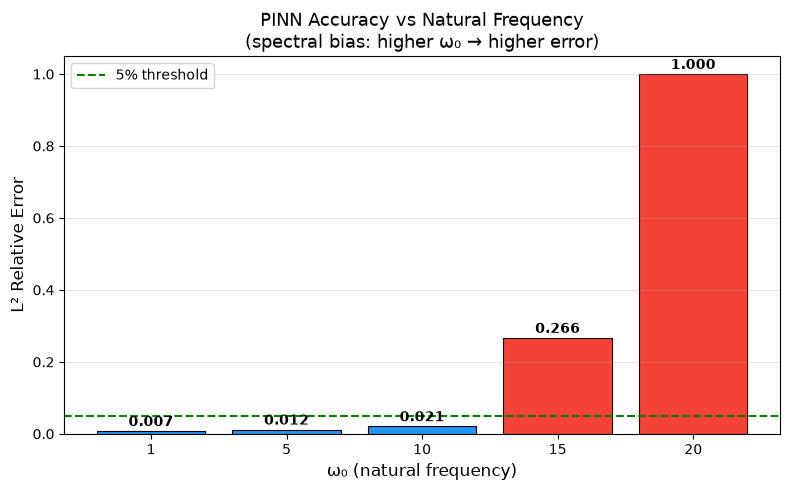

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

l2_errors = [results[w]["l2"] for w in omega_values]
colors = ["#2196F3" if e < 0.1 else "#F44336" for e in l2_errors]

bars = ax.bar([str(w) for w in omega_values], l2_errors, color=colors, edgecolor="black", linewidth=0.8)
for bar, err in zip(bars, l2_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{err:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(0.05, color="green", ls="--", lw=1.5, label="5% threshold")
ax.set_xlabel("ω₀ (natural frequency)", fontsize=12)
ax.set_ylabel("L² Relative Error", fontsize=12)
ax.set_title("PINN Accuracy vs Natural Frequency\n(spectral bias: higher ω₀ → higher error)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Plot 2 — Worst-Case: Predicted vs Exact x(t)

Worst ω₀ = 20  (L² = 0.9999)


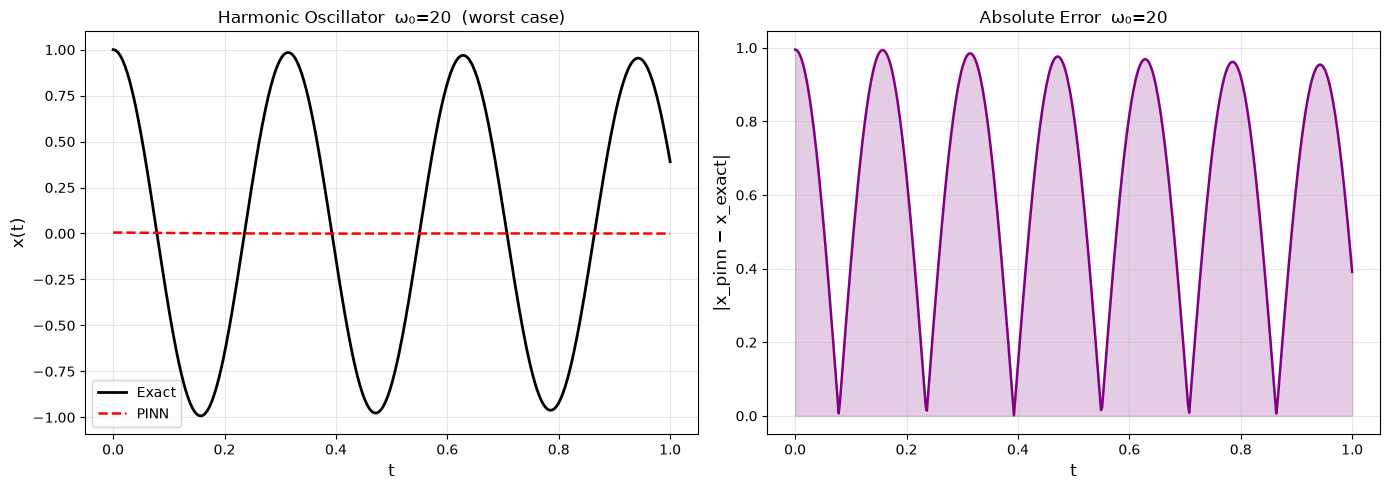

In [6]:
worst_omega = omega_values[np.argmax([results[w]["l2"] for w in omega_values])]
r = results[worst_omega]

print(f"Worst ω₀ = {worst_omega}  (L² = {r['l2']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solution curves
axes[0].plot(r["t"], r["exact"], "k-",  lw=2, label="Exact")
axes[0].plot(r["t"], r["pred"],  "r--", lw=1.8, label="PINN")
axes[0].set_xlabel("t", fontsize=12)
axes[0].set_ylabel("x(t)", fontsize=12)
axes[0].set_title(f"Harmonic Oscillator  ω₀={worst_omega}  (worst case)", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Absolute error
axes[1].plot(r["t"], np.abs(r["pred"] - r["exact"]), "purple", lw=1.8)
axes[1].set_xlabel("t", fontsize=12)
axes[1].set_ylabel("|x_pinn − x_exact|", fontsize=12)
axes[1].set_title(f"Absolute Error  ω₀={worst_omega}", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(r["t"], np.abs(r["pred"] - r["exact"]), alpha=0.2, color="purple")

plt.tight_layout()
plt.show()

### Training Loss Curves — All ω₀

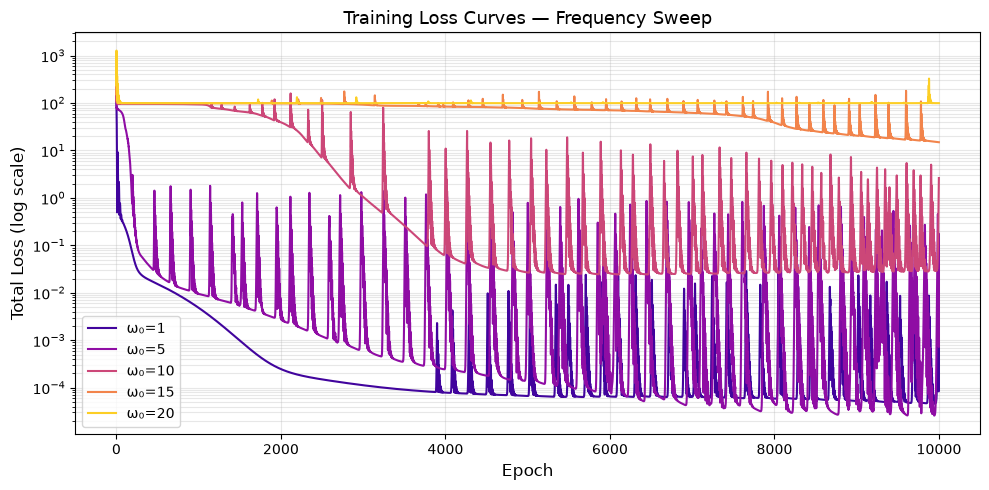

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_sweep = plt.cm.plasma(np.linspace(0.1, 0.9, len(omega_values)))

for omega0, c in zip(omega_values, colors_sweep):
    ax.semilogy(results[omega0]["losses"], label=f"ω₀={omega0}", color=c, lw=1.5)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Total Loss (log scale)", fontsize=12)
ax.set_title("Training Loss Curves — Frequency Sweep", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

---
## Task 2 — Written Reflection

### Q1: What is spectral bias, and what does your experiment demonstrate?

**Spectral bias** (also called *frequency principle*) is the tendency of neural networks trained with gradient descent to learn low-frequency components of a function first, and high-frequency components only slowly — or not at all within a limited training budget.

In the frequency sweep above, the PINN achieves a low L² error for ω₀=1 (a slowly oscillating signal) but its error grows substantially at ω₀=15 or ω₀=20. The network struggles to represent the rapid oscillations because its weights preferentially converge to smooth, low-frequency mappings.

Concretely: the PDE residual for large ω₀ requires the network to produce high-curvature outputs, but early in training those gradients are dominated by lower-frequency modes of the loss landscape.

---

### Q2: What would you try to fix the high-frequency failure?

Several approaches are possible:

1. **Fourier feature embeddings:** Instead of feeding raw `t`, encode `t` as `[sin(2πft), cos(2πft), ...]` for a range of frequencies `f`. This explicitly gives the network access to the relevant high-frequency modes.
2. **Modified activation functions (e.g. `sin`, SIREN):** Sinusoidal activations (as in Sitzmann et al. 2020) naturally represent high-frequency functions.
3. **Adaptive sampling:** Concentrate more collocation points in regions where the residual is large (typically where oscillations are fastest).
4. **Curriculum learning:** Start with a short time horizon and gradually extend it as training progresses.


---
## Summary Table

In [8]:
print(f"{'ω₀':>6} | {'Final Loss':>12} | {'L² Error':>10}")
print("-" * 36)
for omega0 in omega_values:
    r = results[omega0]
    print(f"{omega0:>6} | {r['losses'][-1]:>12.4e} | {r['l2']:>10.4f}")

    ω₀ |   Final Loss |   L² Error
------------------------------------
     1 |   3.0416e-03 |     0.0075
     5 |   2.7139e-02 |     0.0116
    10 |   2.6242e+00 |     0.0209
    15 |   1.4923e+01 |     0.2664
    20 |   9.9429e+01 |     0.9999
